# Unimodal Visual Sensitivity: Aggregation, Analysis & Figures

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')

BASE_DIR = 'unimodal/image_corruptions'
BASELINE_CSV = 'evaluation/baseline_iou_all.csv'
OUTPUT_DIR = 'evaluation/visual'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## Constants & Mappings

In [2]:
CATEGORY_MAP = {
    'jpeg_filter': 'Digital', 'pixelate': 'Digital',
    'defocus_blur': 'Blur', 'motion_blur': 'Blur',
    'gaussian_noise': 'Noise',
    'false_color': 'Color', 'grayscale': 'Color', 'contrast': 'Color',
    'elastic': 'Geometric', 'cutout': 'Geometric',
    'snow_filter': 'Weather', 'fog_filter': 'Weather',
}

NICE_NAMES = {
    'jpeg_filter': 'JPEG Compression', 'pixelate': 'Pixelation',
    'defocus_blur': 'Defocus Blur', 'motion_blur': 'Motion Blur',
    'gaussian_noise': 'Gaussian Noise',
    'fog_filter': 'Fog Overlay', 'snow_filter': 'Snow Overlay',
    'contrast': 'Contrast', 'elastic': 'Elastic Transform',
    'cutout': 'BB-Aware Cutout',
    'false_color': 'False Color', 'grayscale': 'Grayscale Blend',
}

CATEGORY_ORDER = ['Digital', 'Blur', 'Noise', 'Color', 'Geometric', 'Weather']

CORR_COLORS = {
    'jpeg_filter': '#1f77b4', 'pixelate': '#ff7f0e',
    'defocus_blur': '#2ca02c', 'motion_blur': '#d62728',
    'gaussian_noise': '#1f77b4',
    'fog_filter': '#ff7f0e', 'snow_filter': '#2ca02c', 'contrast': '#d62728',
    'elastic': '#1f77b4', 'cutout': '#ff7f0e',
    'false_color': '#2ca02c', 'grayscale': '#d62728',
}

CAT_COLORS = {
    'Digital': '#e41a1c', 'Blur': '#377eb8', 'Noise': '#4daf4a',
    'Color': '#984ea3', 'Geometric': '#ff7f00', 'Weather': '#a65628',
}

SCENE_COLORS = {
    'Isolated':  '#4878A8',
    'Clustered': '#E8913A',
    'Mixed':     '#59A668',
}
SCENE_MARKERS = {'Isolated': 'o', 'Clustered': 's', 'Mixed': '^'}
SCENE_ORDER = ['Isolated', 'Clustered', 'Mixed']

RETAINED = {'jpeg_filter', 'pixelate', 'defocus_blur', 'motion_blur', 'gaussian_noise', 'fog_filter'}
EXCLUDED = {'snow_filter', 'contrast', 'elastic', 'cutout', 'false_color', 'grayscale'}

def style_ax(ax, grid_major=True, grid_minor=False):
    """Apply shared axis styling matching Baseline_Evaluation.ipynb."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    if grid_major:
        ax.yaxis.grid(True, which='major', ls='-', lw=0.4, alpha=0.5)
        ax.xaxis.grid(False)
    if grid_minor:
        ax.yaxis.grid(True, which='minor', ls=':', lw=0.3, alpha=0.3)

## Load Baseline + Corruption Data

In [3]:
bl = pd.read_csv(BASELINE_CSV)
bl = bl.rename(columns={'iou': 'baseline_iou'})
bl_lookup = bl.set_index(['scene_type', 'sample_id'])['baseline_iou'].to_dict()
print(f'Baseline: {len(bl)} samples loaded')
print(bl.groupby('scene_type')['baseline_iou'].agg(['mean','std','count']).round(4))

Baseline: 750 samples loaded
              mean     std  count
scene_type                       
Clustered   0.8414  0.1261    250
Isolated    0.9226  0.0766    250
Mixed       0.7822  0.1339    250


In [4]:
def get_scene_type(rel_path):
    rel = rel_path.replace('\\', '/')
    if rel.startswith('single/solo'):  return 'Isolated'
    if rel.startswith('single/multi'): return 'Clustered'
    if rel.startswith('multi'):        return 'Mixed'
    return 'Unknown'

rows = []
missing = 0
errors = []

for root, dirs, files in os.walk(BASE_DIR):
    for fname in files:
        if not fname.startswith('scale_') or not fname.endswith('_IMG.json'):
            continue
        fpath = os.path.join(root, fname)
        rel_path = os.path.relpath(root, BASE_DIR)
        sample_id = int(os.path.basename(root))
        scene_type = get_scene_type(rel_path)

        try:
            with open(fpath) as f:
                data = json.load(f)
        except Exception as e:
            errors.append((fpath, str(e))); missing += 1; continue

        sev = data['corruption_scale']
        sev_float = data.get('corruption_scale_float', sev / 4.0)

        for attack, m in data.get('corruptions', {}).items():
            rows.append({
                'sample_id': sample_id, 'scene_type': scene_type,
                'corruption': attack, 'severity': sev, 'severity_float': sev_float,
                'IoU': m.get('IoU', 0.0),
                'frobenius_distance': m.get('frobenius_distance', 0.0),
                'token_count': m.get('token_count', 0),
                'raw_token_count': m.get('raw_token_count', 0),
                'runtime_seconds': m.get('runtime_seconds', 0.0),
            })

df = pd.DataFrame(rows)
df['category'] = df['corruption'].map(CATEGORY_MAP)

df['baseline_iou'] = df.apply(lambda r: bl_lookup.get((r.scene_type, r.sample_id), np.nan), axis=1)

print(f'Rows: {len(df):,}  (expected {750*12*5:,})')
print(f'Missing/error files: {missing}')
print(f'Samples: {df.sample_id.nunique()}, Corruptions: {df.corruption.nunique()}')
print(f'Baseline matched: {df.baseline_iou.notna().sum():,} / {len(df):,}')
print()
print(df.groupby('scene_type')['sample_id'].nunique())

Rows: 45,000  (expected 45,000)
Missing/error files: 0
Samples: 250, Corruptions: 12
Baseline matched: 45,000 / 45,000

scene_type
Clustered    250
Isolated     250
Mixed        250
Name: sample_id, dtype: int64


In [5]:
df.to_csv(os.path.join(OUTPUT_DIR, 'unimodal_visual_flat.csv'), index=False)
print('saved flat csv')

saved flat csv


In [6]:
bl_means = bl.groupby('scene_type')['baseline_iou'].mean().to_dict()
bl_overall = bl['baseline_iou'].mean()
print(f'Baseline means: {bl_means}')
print(f'Overall: {bl_overall:.5f}')

Baseline means: {'Clustered': 0.84142396, 'Isolated': 0.92264948, 'Mixed': 0.7821761199999999}
Overall: 0.84875


## Per-Corruption Sensitivity Profiles

In [7]:
iou_pivot = df.pivot_table(index='corruption', columns='severity', values='IoU', aggfunc='mean').round(3)
frob_pivot = df.pivot_table(index='corruption', columns='severity', values='frobenius_distance', aggfunc='mean').round(3)

iou_pivot.insert(0, 'BL', round(bl_overall, 3))
iou_pivot['drop_BL_to_4'] = (iou_pivot['BL'] - iou_pivot[4]).round(3)
iou_pivot['pct_drop'] = ((iou_pivot['drop_BL_to_4'] / iou_pivot['BL']) * 100).round(1)

iou_pivot = iou_pivot.sort_values('drop_BL_to_4', ascending=False)

print('=== Mean \u0305IoU (with Baseline) ===')
display(iou_pivot)
print()
print('=== Mean Frobenius Distance ===')
display(frob_pivot)

=== Mean ̅IoU (with Baseline) ===


severity,BL,0,1,2,3,4,drop_BL_to_4,pct_drop
corruption,,,,,,,,
pixelate,0.849,0.831,0.834,0.820,0.774,0.655,0.194,22.9
defocus_blur,0.849,0.837,0.804,0.784,0.746,0.693,0.156,18.4
motion_blur,0.849,0.837,0.837,0.833,0.818,0.744,0.105,12.4
fog_filter,0.849,0.843,0.843,0.837,0.823,0.756,0.093,11.0
jpeg_filter,0.849,0.820,0.822,0.817,0.808,0.756,0.093,11.0
false_color,0.849,0.832,0.829,0.836,0.803,0.760,0.089,10.5
gaussian_noise,0.849,0.840,0.830,0.813,0.791,0.765,0.084,9.9
elastic,0.849,0.820,0.819,0.799,0.795,0.786,0.063,7.4
cutout,0.849,0.840,0.833,0.825,0.815,0.799,0.050,5.9



=== Mean Frobenius Distance ===


severity,0,1,2,3,4
corruption,,,,,
contrast,0.024,0.044,0.062,0.091,0.113
cutout,0.054,0.082,0.117,0.146,0.187
defocus_blur,0.054,0.079,0.083,0.094,0.102
elastic,0.078,0.060,0.072,0.074,0.079
false_color,0.139,0.086,0.142,0.556,0.313
fog_filter,0.060,0.115,0.160,0.223,0.291
gaussian_noise,0.029,0.058,0.112,0.162,0.193
grayscale,0.009,0.017,0.030,0.047,0.072
jpeg_filter,0.040,0.047,0.050,0.057,0.073


In [8]:
iou_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2a_iou_per_corruption.csv'))
frob_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2a_frob_per_corruption.csv'))
print('saved')

saved


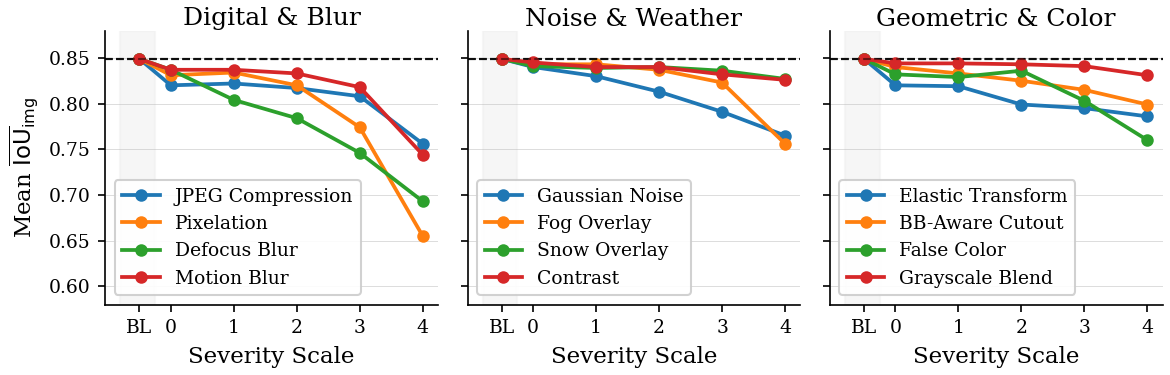

In [9]:
# ============================================================
# FIGURE 1: degradation curves grouped by category (3 panels)
#           baseline shown as leftmost point for each corruption
# ============================================================

panel_groups = [
    ('Digital & Blur', ['jpeg_filter', 'pixelate', 'defocus_blur', 'motion_blur']),
    ('Noise & Weather', ['gaussian_noise', 'fog_filter', 'snow_filter', 'contrast']),
    ('Geometric & Color', ['elastic', 'cutout', 'false_color', 'grayscale']),
]

x_labels = ['BL', '0', '1', '2', '3', '4']
x_pos = np.array([-0.5, 0, 1, 2, 3, 4])  # slight gap between BL and 0

fig, axes = plt.subplots(1, 3, figsize=(8, 2.7), sharey=True)

for ax, (title, corrs) in zip(axes, panel_groups):
    for corr in corrs:
        if corr not in iou_pivot.index:
            continue
        vals = [iou_pivot.loc[corr, 'BL']] + [iou_pivot.loc[corr, s] for s in [0,1,2,3,4]]
        ax.plot(x_pos, vals, marker='o', markersize=5, linewidth=1.8,
                color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

        ax.axhline(bl_overall, color='black', ls='--', lw=1, alpha=0.5)
    ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Severity Scale')
    ax.set_title(title, pad=0)
    ax.legend(loc='lower left', framealpha=0.9)
    style_ax(ax)
    ax.set_ylim(0.58, 0.88)

axes[0].set_ylabel('Mean $\\overline{\mathrm{IoU}}_{\mathrm{img}}$')

# fig.suptitle('Performance Degradation: Baseline $\overline{\mathrm{IoU}}_{0}$ vs. Mean $\overline{\mathrm{IoU}}_{img}$ for each $S_i$',
#              fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_3panel.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_3panel.png'))
plt.show()

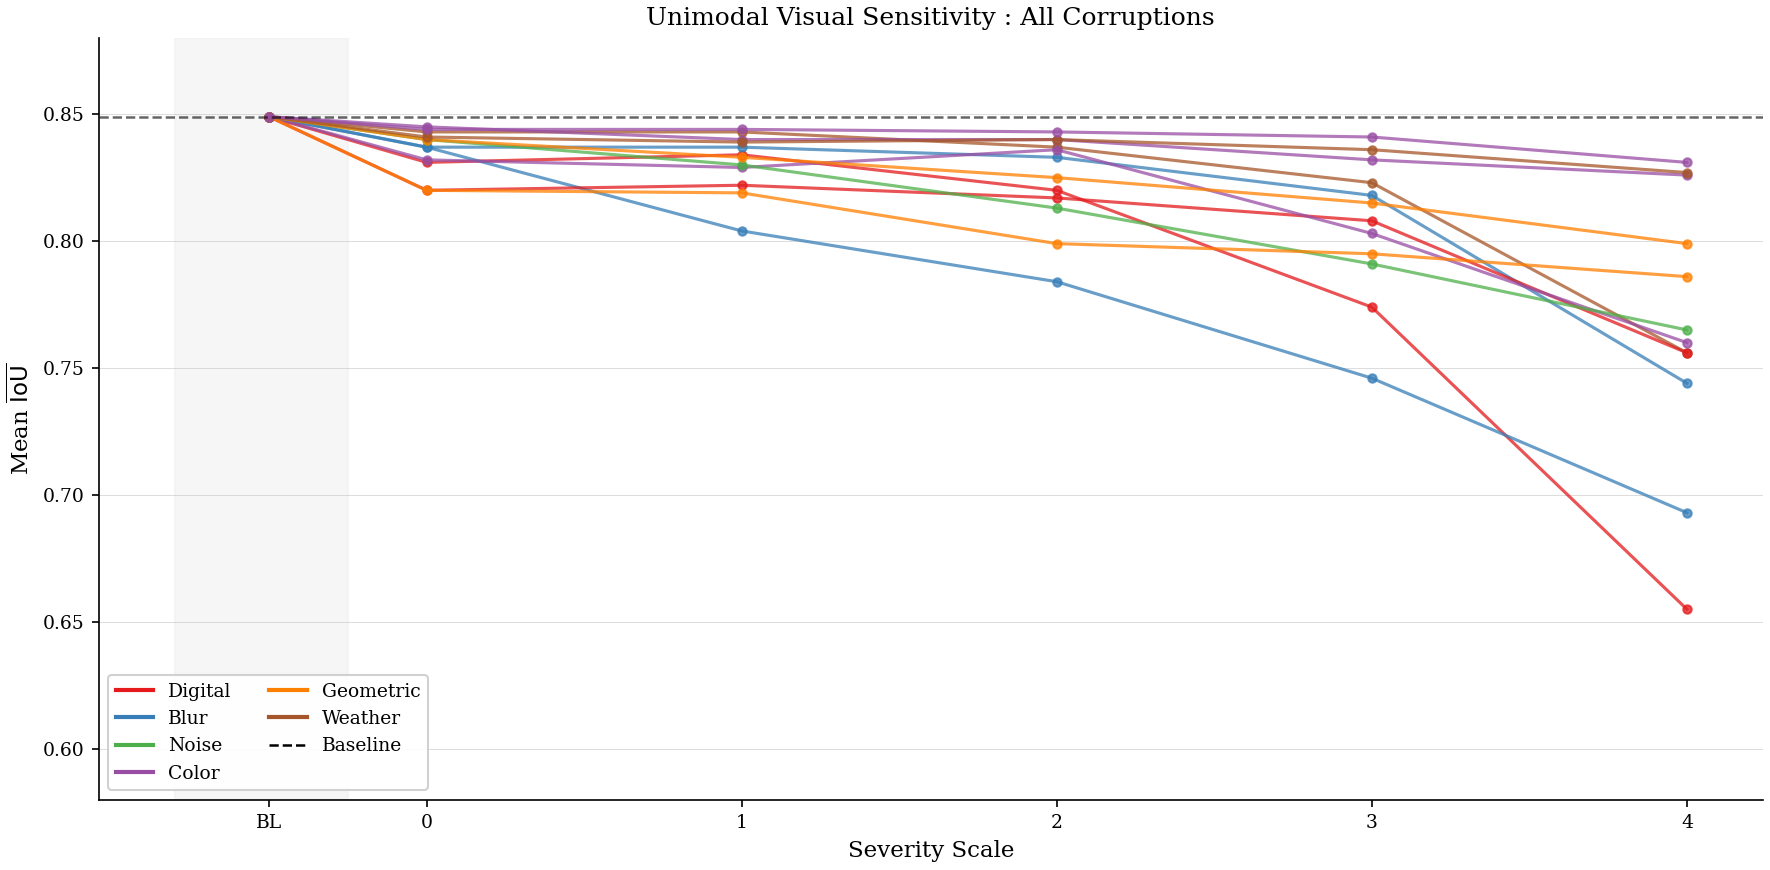

In [10]:
# ============================================================
# FIGURE 2: single combined plot : all 12 corruptions, colored by category
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for corr in iou_pivot.index:
    cat = CATEGORY_MAP[corr]
    vals = [iou_pivot.loc[corr, 'BL']] + [iou_pivot.loc[corr, s] for s in [0,1,2,3,4]]
    ax.plot(x_pos, vals, marker='o', markersize=4, linewidth=1.5,
            color=CAT_COLORS[cat], alpha=0.75,
            label=f'{NICE_NAMES.get(corr, corr)}')

ax.axhline(bl_overall, color='black', ls='--', lw=1.2, alpha=0.6, label=f'Baseline (mean={bl_overall:.3f})')
ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\\overline{\mathrm{IoU}}$')
ax.set_title('Unimodal Visual Sensitivity : All Corruptions')
ax.set_ylim(0.58, 0.88)

handles = [Line2D([0],[0], color=CAT_COLORS[c], lw=2, label=c) for c in CATEGORY_ORDER]
handles.append(Line2D([0],[0], color='black', ls='--', lw=1.2, label='Baseline'))
ax.legend(handles=handles, loc='lower left', ncol=2, framealpha=0.9)

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_all_combined.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_degradation_all_combined.png'))
plt.show()

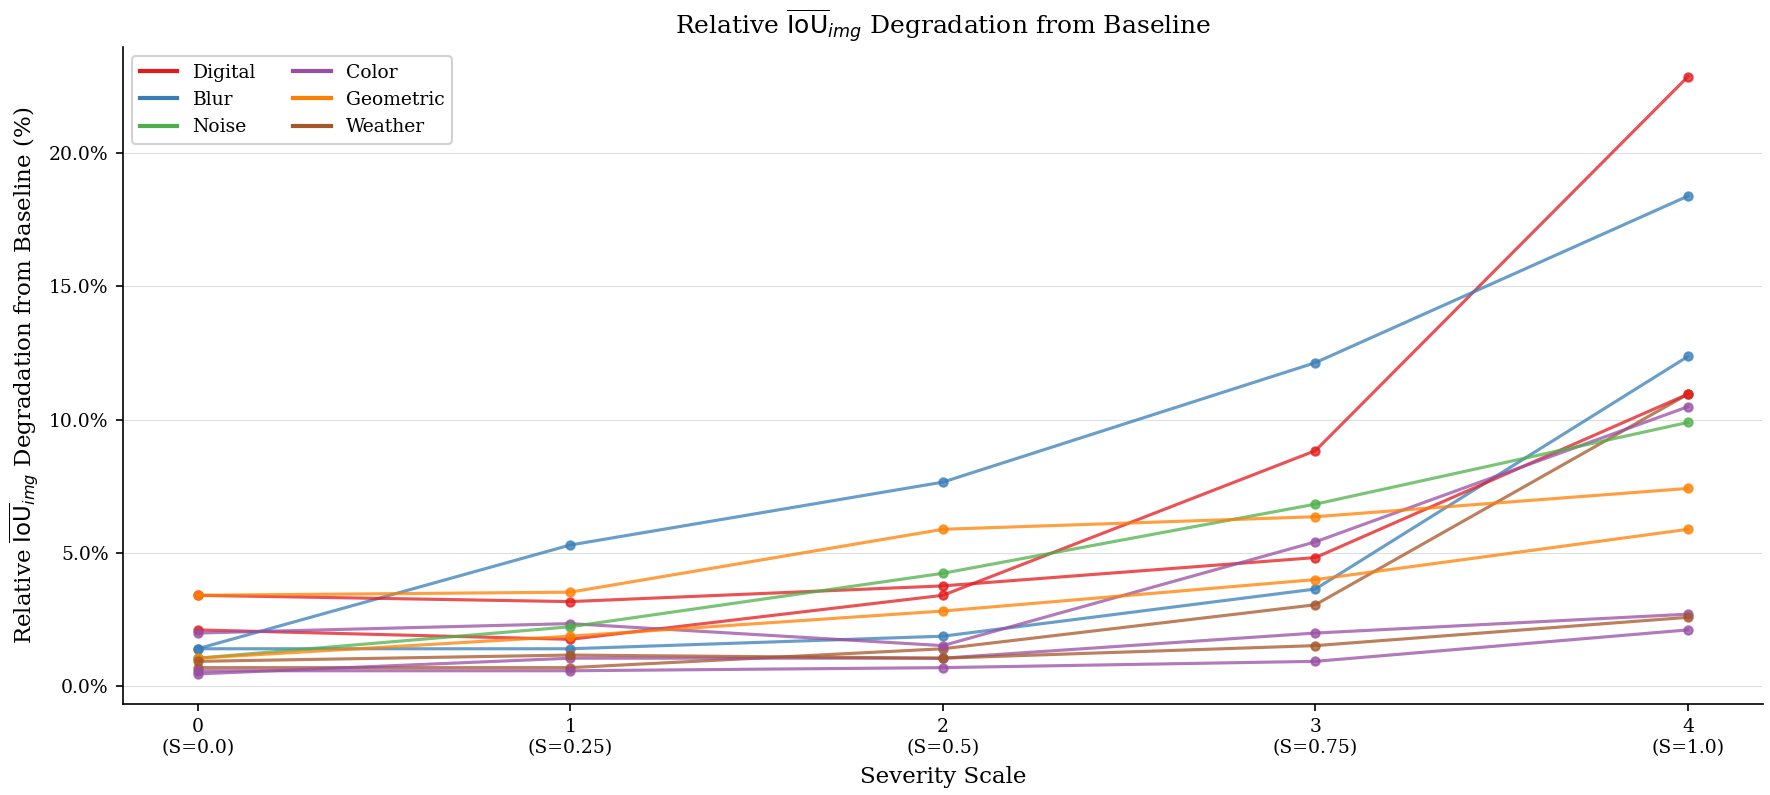

In [11]:
# ============================================================
# FIGURE 3: relative degradation from baseline (percentage drop)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5.5))

for corr in iou_pivot.index:
    cat = CATEGORY_MAP[corr]
    base = iou_pivot.loc[corr, 'BL']
    pct_drop = [(base - iou_pivot.loc[corr, s]) / base * 100 for s in [0,1,2,3,4]]
    ax.plot(range(5), pct_drop, marker='o', markersize=4, linewidth=1.5,
            color=CAT_COLORS[cat], alpha=0.75)

handles = [Line2D([0],[0], color=CAT_COLORS[c], lw=2, label=c) for c in CATEGORY_ORDER]
ax.legend(handles=handles, loc='upper left', ncol=2, framealpha=0.9)

ax.set_xticks(range(5))
ax.set_xticklabels(['0\n(S=0.0)', '1\n(S=0.25)', '2\n(S=0.5)', '3\n(S=0.75)', '4\n(S=1.0)'])
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Relative $\overline{\mathrm{IoU}}_{img}$ Degradation from Baseline (%)')
ax.set_title('Relative $\overline{\mathrm{IoU}}_{img}$ Degradation from Baseline')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_relative_degradation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_relative_degradation.png'))
plt.show()

Top 4 most damaging at sev 4: ['pixelate', 'defocus_blur', 'motion_blur', 'jpeg_filter']


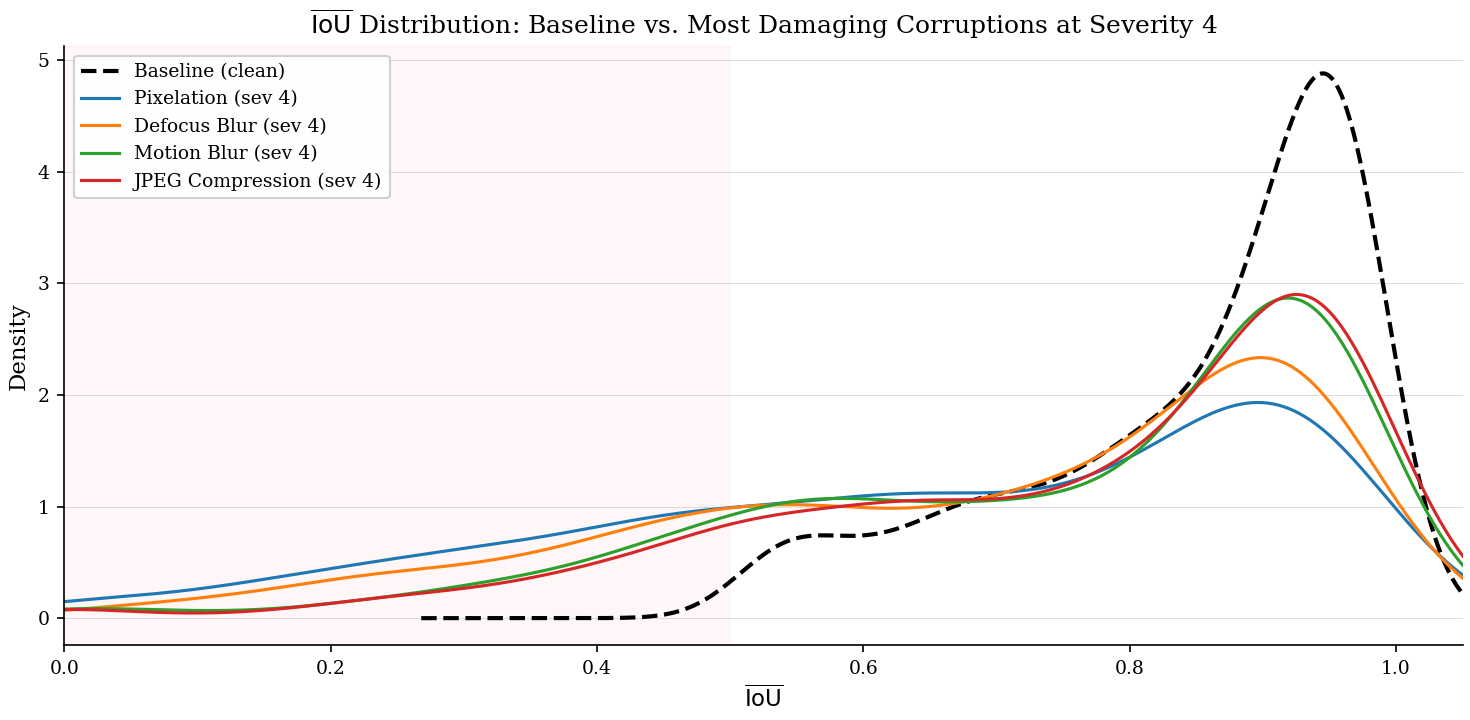

In [12]:
# ============================================================
# FIGURE 4: IoU distribution at severity 4 vs baseline (KDE)
# ============================================================

sev4_rank = df[df.severity == 4].groupby('corruption')['IoU'].mean().sort_values()
top4_damaging = sev4_rank.head(4).index.tolist()
print('Top 4 most damaging at sev 4:', top4_damaging)

fig, ax = plt.subplots(figsize=(10, 5))

bl['baseline_iou'].plot.kde(ax=ax, color='black', ls='--', lw=2, label='Baseline (clean)')

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for corr, col in zip(top4_damaging, palette):
    sub = df[(df.corruption == corr) & (df.severity == 4)]
    sub['IoU'].plot.kde(ax=ax, color=col, lw=1.5, label=f'{NICE_NAMES.get(corr, corr)} (sev 4)')

ax.axvspan(0, 0.5, color='#ffcccc', alpha=0.15, zorder=0)
ax.set_xlim(0, 1.05)
ax.set_xlabel('$\\overline{\mathrm{IoU}}$')
ax.set_ylabel('Density')
ax.set_title('$\overline{\mathrm{IoU}}$ Distribution: Baseline vs. Most Damaging Corruptions at Severity 4')
ax.legend(framealpha=0.9)

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_kde_baseline_vs_top4.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_kde_baseline_vs_top4.png'))
plt.show()

In [13]:
# ============================================================
# FIGURE 5: KL divergence from baseline distribution per corruption
# ============================================================

def kl_divergence_binned(p_vals, q_vals, bins=50, eps=1e-10):
    """KL(p || q) using histogram binning"""
    edges = np.linspace(0, 1, bins + 1)
    p_hist, _ = np.histogram(p_vals, bins=edges, density=True)
    q_hist, _ = np.histogram(q_vals, bins=edges, density=True)
    p_hist = p_hist / (p_hist.sum() + eps) + eps
    q_hist = q_hist / (q_hist.sum() + eps) + eps
    return float(np.sum(p_hist * np.log(p_hist / q_hist)))

bl_vals = bl['baseline_iou'].values

kl_rows = []
for sev in range(5):
    for corr in df.corruption.unique():
        sub = df[(df.corruption == corr) & (df.severity == sev)]
        kl = kl_divergence_binned(sub['IoU'].values, bl_vals)
        kl_rows.append({'corruption': corr, 'severity': sev,
                        'category': CATEGORY_MAP[corr], 'kl_div': kl})

kl_df = pd.DataFrame(kl_rows)
kl_pivot = kl_df.pivot_table(index='corruption', columns='severity', values='kl_div').round(5)
print(kl_pivot)

severity              0        1        2        3        4
corruption                                                 
contrast        0.18895  0.31011  0.26213  0.46617  0.61611
cutout          0.22723  0.48637  0.44632  0.68485  0.86580
defocus_blur    0.49944  1.37034  1.81139  2.63520  4.22552
elastic         1.00130  0.94129  1.50947  1.67633  1.88424
false_color     0.56636  0.70174  0.48148  1.43407  2.35837
fog_filter      0.21078  0.22743  0.36748  0.81144  2.44111
gaussian_noise  0.43585  0.69194  0.95657  1.50141  2.18095
grayscale       0.11680  0.13846  0.20530  0.35846  0.60683
jpeg_filter     0.79674  0.79464  0.86406  1.13044  2.48260
motion_blur     0.35046  0.45256  0.57642  0.97787  2.64246
pixelate        0.50489  0.63984  0.91898  1.97554  5.21348
snow_filter     0.27626  0.35020  0.34447  0.50002  0.77443


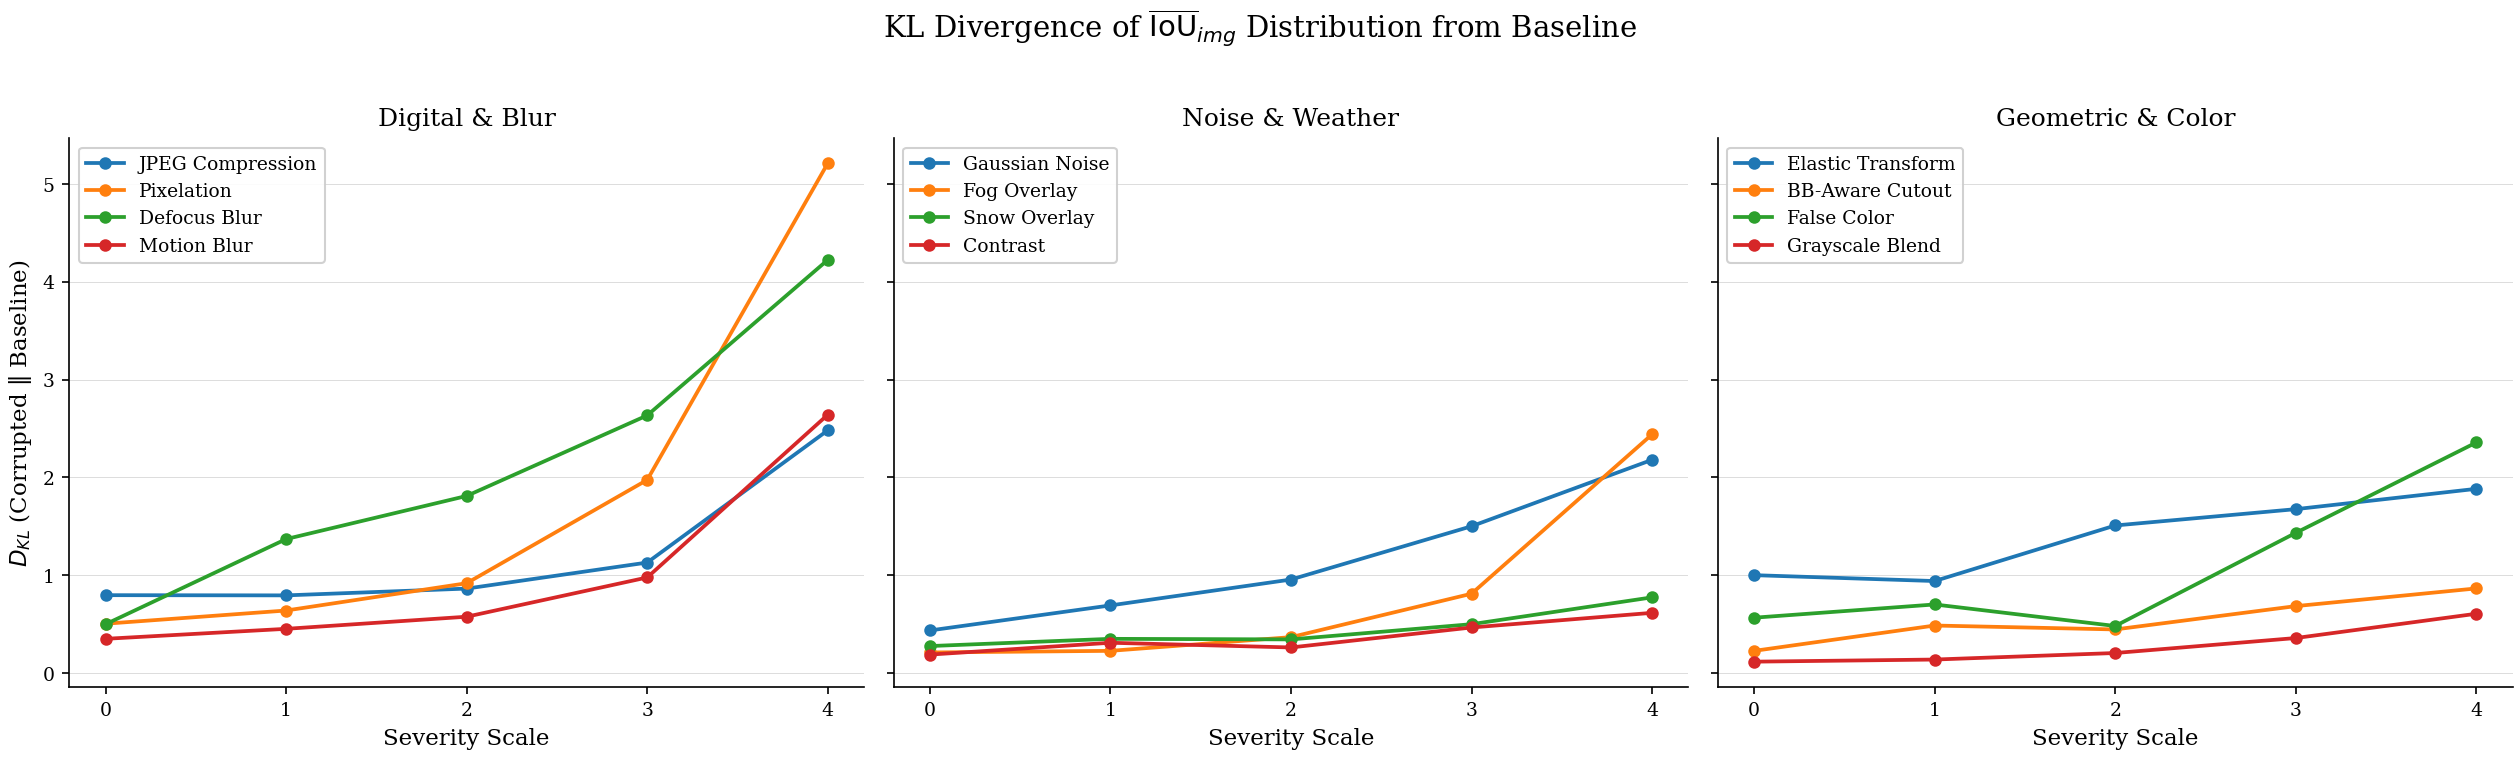

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (title, corrs) in zip(axes, panel_groups):
    for corr in corrs:
        if corr not in kl_pivot.index: continue
        vals = [kl_pivot.loc[corr, s] for s in range(5)]
        ax.plot(range(5), vals, marker='o', markersize=5, linewidth=1.8,
                color=CORR_COLORS[corr], label=NICE_NAMES.get(corr, corr))

    ax.set_xticks(range(5))
    ax.set_xlabel('Severity Scale')
    ax.set_title(title)
    ax.legend(loc='upper left', framealpha=0.9)
    style_ax(ax)

axes[0].set_ylabel('$D_{KL}$ (Corrupted $\\|$ Baseline)')

fig.suptitle('KL Divergence of $\overline{\mathrm{IoU}}_{img}$ Distribution from Baseline',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_kl_divergence_3panel.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_kl_divergence_3panel.png'))
plt.show()

## Corruption Category Analysis

In [15]:
cat_pivot = df.pivot_table(index='category', columns='severity', values='IoU', aggfunc='mean').round(5)
cat_pivot.insert(0, 'BL', bl_overall)
cat_pivot['drop_BL_to_4'] = (cat_pivot['BL'] - cat_pivot[4]).round(5)
cat_pivot = cat_pivot.reindex([c for c in CATEGORY_ORDER if c in cat_pivot.index])

display(cat_pivot)
cat_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2b_category_iou.csv'))

severity,BL,0,1,2,3,4,drop_BL_to_4
category,,,,,,,
Digital,0.84875,0.82522,0.82784,0.81851,0.79082,0.70527,0.14348
Blur,0.84875,0.83676,0.82041,0.80842,0.78202,0.71842,0.13033
Noise,0.84875,0.84010,0.82997,0.81265,0.79054,0.76508,0.08367
Color,0.84875,0.84036,0.83768,0.83961,0.82552,0.80543,0.04332
Geometric,0.84875,0.82996,0.82574,0.81206,0.80485,0.79245,0.05630
Weather,0.84875,0.84180,0.84132,0.83839,0.82908,0.79135,0.05740


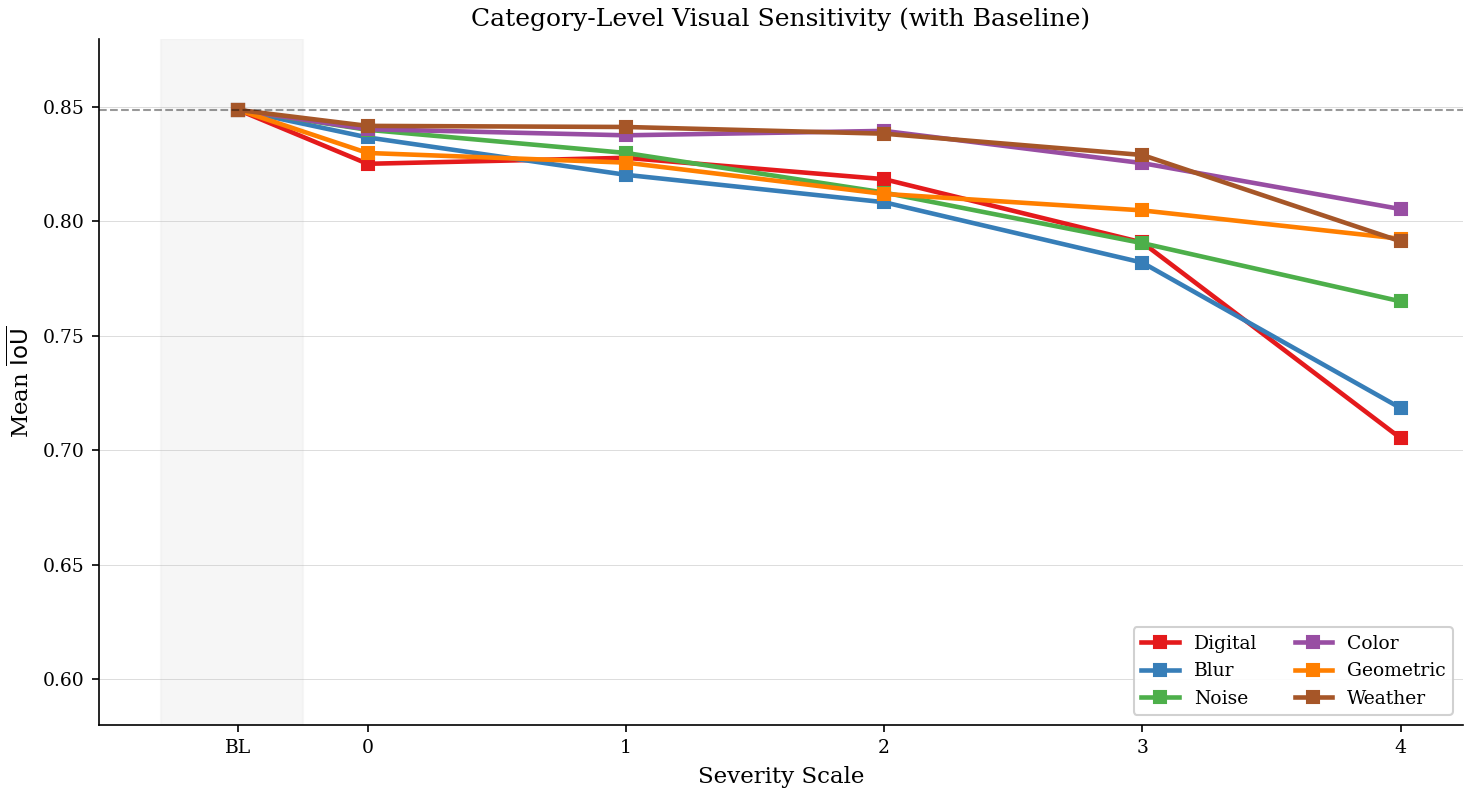

In [16]:
# ============================================================
# FIGURE 6: category-level degradation from baseline
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

for cat in CATEGORY_ORDER:
    if cat not in cat_pivot.index: continue
    vals = [cat_pivot.loc[cat, 'BL']] + [cat_pivot.loc[cat, s] for s in range(5)]
    ax.plot(x_pos, vals, marker='s', markersize=6, linewidth=2.2,
            color=CAT_COLORS[cat], label=cat)

ax.axhline(bl_overall, color='black', ls='--', lw=1, alpha=0.4)
ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\\overline{\mathrm{IoU}}$')
ax.set_title('Category-Level Visual Sensitivity (with Baseline)')
ax.legend(framealpha=0.9, ncol=2)
ax.set_ylim(0.58, 0.88)

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_degradation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_degradation.png'))
plt.show()

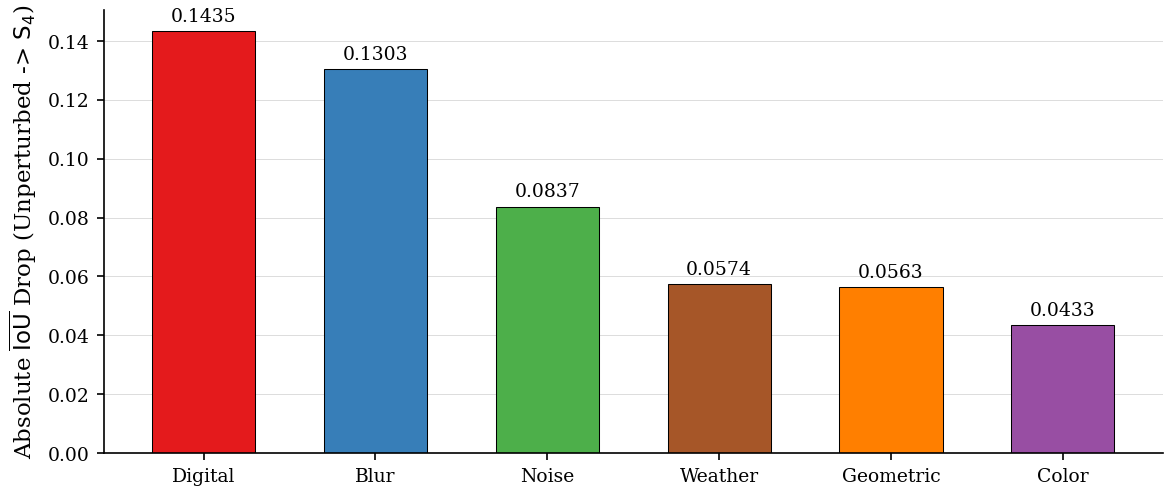

In [17]:
# ============================================================
# FIGURE 7: bar chart : IoU drop (BL -> sev 4) per category, sorted by magnitude
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.5))

sorted_cats = cat_pivot['drop_BL_to_4'].sort_values(ascending=False)
cats = sorted_cats.index.tolist()
drops = sorted_cats.values
colors = [CAT_COLORS.get(c, '#888') for c in cats]

bars = ax.bar(cats, drops, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
for bar, val in zip(bars, drops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Absolute $\overline{\mathrm{IoU}}$ Drop (Unperturbed -> $\mathrm{S}_4$)')
ax.set_title('')

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_bar_drop.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_category_bar_drop.png'))
plt.show()

## Scene-Type Sensitivity

In [18]:
scene_pivot = df.pivot_table(
    index=['corruption', 'scene_type'], columns='severity',
    values='IoU', aggfunc='mean'
).round(5)

display(scene_pivot)
scene_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2c_scene_type_iou.csv'))

severity                         0        1        2        3        4
corruption     scene_type                                             
contrast       Clustered   0.83519  0.83651  0.83034  0.81138  0.81384
               Isolated    0.92068  0.92094  0.92044  0.91971  0.91060
               Mixed       0.77846  0.76138  0.77065  0.76557  0.75274
cutout         Clustered   0.83485  0.82349  0.81020  0.79876  0.77794
               Isolated    0.91629  0.91467  0.90332  0.89663  0.88036
               Mixed       0.76991  0.75945  0.76173  0.74869  0.73820
defocus_blur   Clustered   0.83178  0.78132  0.74672  0.71024  0.65107
               Isolated    0.91865  0.90280  0.89788  0.86183  0.82347
               Mixed       0.76026  0.72732  0.70792  0.66652  0.60508
elastic        Clustered   0.79967  0.79726  0.77932  0.77216  0.76223
               Isolated    0.91332  0.91139  0.89687  0.90396  0.89205
               Mixed       0.74574  0.74817  0.72093  0.70893  0.70391
false_color    Clustered   0.81769  0.81702  0.82045  0.78144  0.73844
               Isolated    0.91929  0.91399  0.92097  0.90162  0.85716
               Mixed       0.75963  0.75580  0.76572  0.72601  0.68321
fog_filter     Clustered   0.83177  0.82996  0.82300  0.80989  0.72407
               Isolated    0.92097  0.91929  0.91836  0.91327  0.86770
               Mixed       0.77490  0.78024  0.76848  0.74436  0.67585
gaussian_noise Clustered   0.82224  0.81421  0.78851  0.76536  0.73062
               Isolated    0.92009  0.91668  0.91102  0.88618  0.87942
               Mixed       0.77795  0.75902  0.73841  0.72009  0.68520
grayscale      Clustered   0.83602  0.84041  0.83980  0.83301  0.82157
               Isolated    0.91958  0.92024  0.91851  0.91976  0.91249
               Mixed       0.77666  0.77285  0.76956  0.77114  0.75881
jpeg_filter    Clustered   0.80963  0.81444  0.80805  0.78610  0.73747
               Isolated    0.90716  0.90788  0.90636  0.90284  0.85565
               Mixed       0.74196  0.74317  0.73728  0.73471  0.67350
motion_blur    Clustered   0.82607  0.83073  0.82204  0.80115  0.71122
               Isolated    0.92125  0.92174  0.91372  0.90817  0.85884
               Mixed       0.76258  0.75854  0.76228  0.74418  0.66081
pixelate       Clustered   0.81706  0.81705  0.80420  0.75112  0.62351
               Isolated    0.91639  0.91520  0.90517  0.87879  0.78100
               Mixed       0.75910  0.76928  0.74999  0.69134  0.56048
snow_filter    Clustered   0.83419  0.83027  0.83096  0.82312  0.81493
               Isolated    0.91749  0.91888  0.91732  0.91395  0.91012
               Mixed       0.77145  0.76927  0.77223  0.76989  0.75546

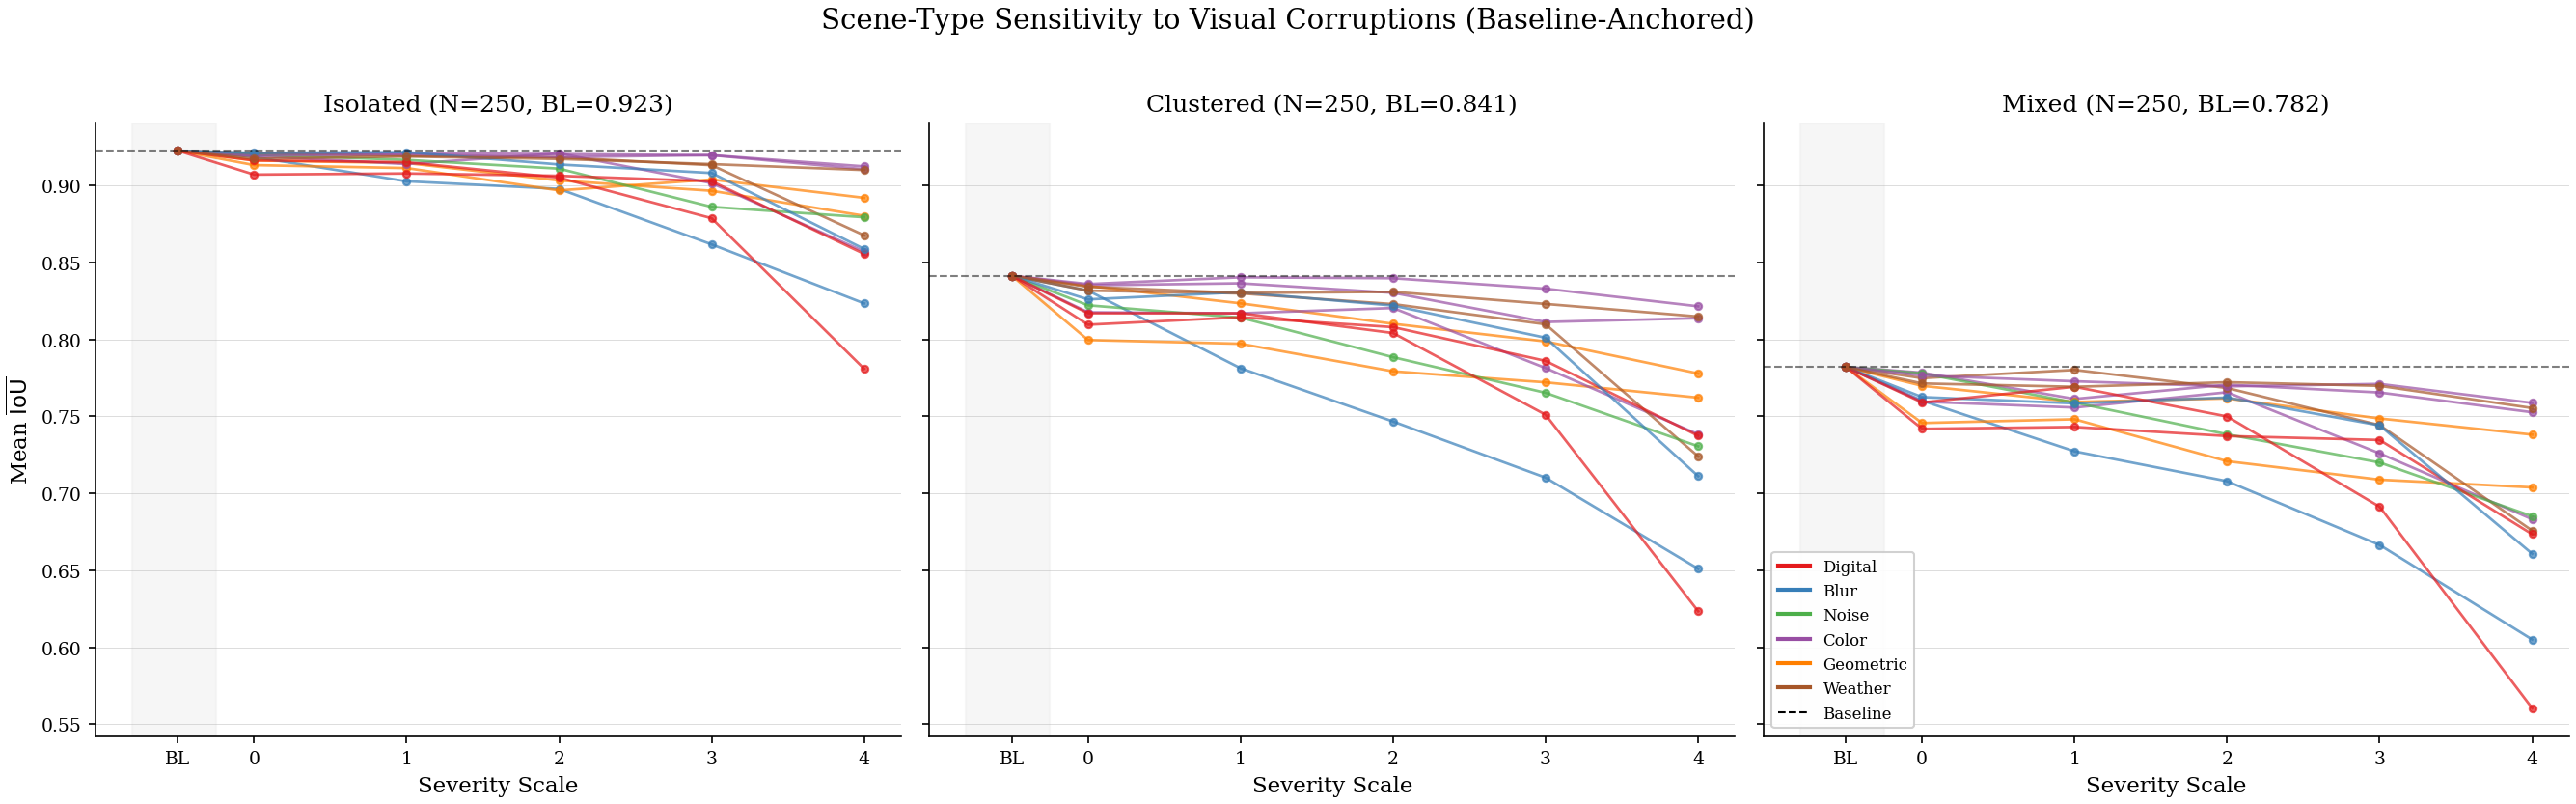

In [19]:
# ============================================================
# FIGURE 8: faceted line plots : one per scene type, BL anchored
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for ax, st in zip(axes, SCENE_ORDER):
    sub = df[df.scene_type == st]
    piv = sub.pivot_table(index='corruption', columns='severity', values='IoU', aggfunc='mean')
    bl_st = bl_means[st]

    for corr in sorted(piv.index):
        cat = CATEGORY_MAP.get(corr, 'Other')
        vals = [bl_st] + [piv.loc[corr, s] for s in range(5)]
        ax.plot(x_pos, vals, marker='o', markersize=3.5, linewidth=1.3,
                color=CAT_COLORS.get(cat, '#999'), alpha=0.7)

    ax.axhline(bl_st, color='black', ls='--', lw=1, alpha=0.5)
    ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)

    n_samples = sub.sample_id.nunique()
    ax.set_title(f'{st} (N={n_samples}, BL={bl_st:.3f})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Severity Scale')
    style_ax(ax)

axes[0].set_ylabel('Mean $\\overline{\mathrm{IoU}}$')

handles = [Line2D([0],[0], color=CAT_COLORS[c], lw=2, label=c) for c in CATEGORY_ORDER]
handles.append(Line2D([0],[0], color='black', ls='--', lw=1, label='Baseline'))
axes[2].legend(handles=handles, loc='lower left', fontsize=8, framealpha=0.9)

fig.suptitle('Scene-Type Sensitivity to Visual Corruptions (Baseline-Anchored)',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_facets.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_facets.png'))
plt.show()

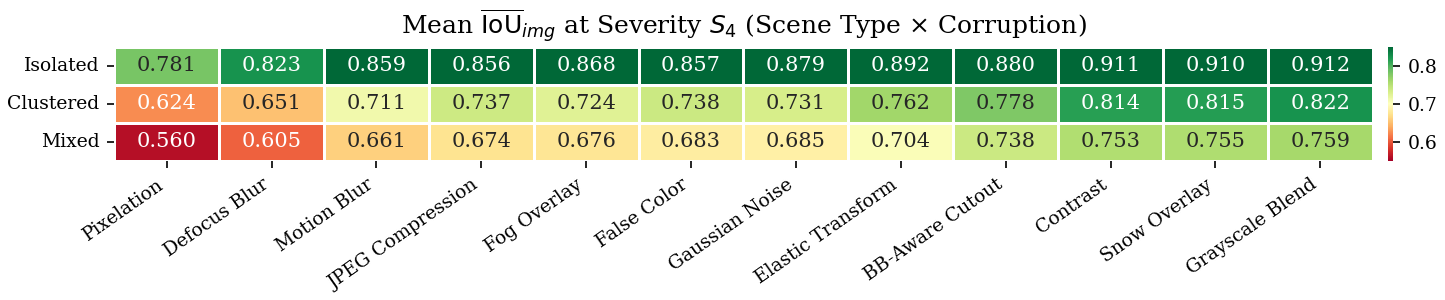

In [20]:
# ============================================================
# FIGURE 9: heatmap : mean IoU at sev 4, corruption x scene type (HORIZONTAL)
# ============================================================

sev4_scene = df[df.severity == 4].pivot_table(
    index='corruption', columns='scene_type', values='IoU', aggfunc='mean'
)[SCENE_ORDER].round(3)

sev4_scene['mean'] = sev4_scene.mean(axis=1)
sev4_scene = sev4_scene.sort_values('mean')
sev4_scene = sev4_scene.drop(columns='mean')

sev4_h = sev4_scene.T
sev4_h.columns = [NICE_NAMES.get(c, c) for c in sev4_h.columns]

fig, ax = plt.subplots(figsize=(11, 2.2))
sns.heatmap(sev4_h, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.6, vmin=0.55, vmax=0.85, ax=ax,
            cbar_kws={'shrink': 1.0, 'pad': 0.01})
ax.set_title('Mean $\overline{\mathrm{IoU}}_{img}$ at Severity $S_4$ (Scene Type × Corruption)')
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_heatmap_sev4_scene.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_heatmap_sev4_scene.png'))
plt.show()

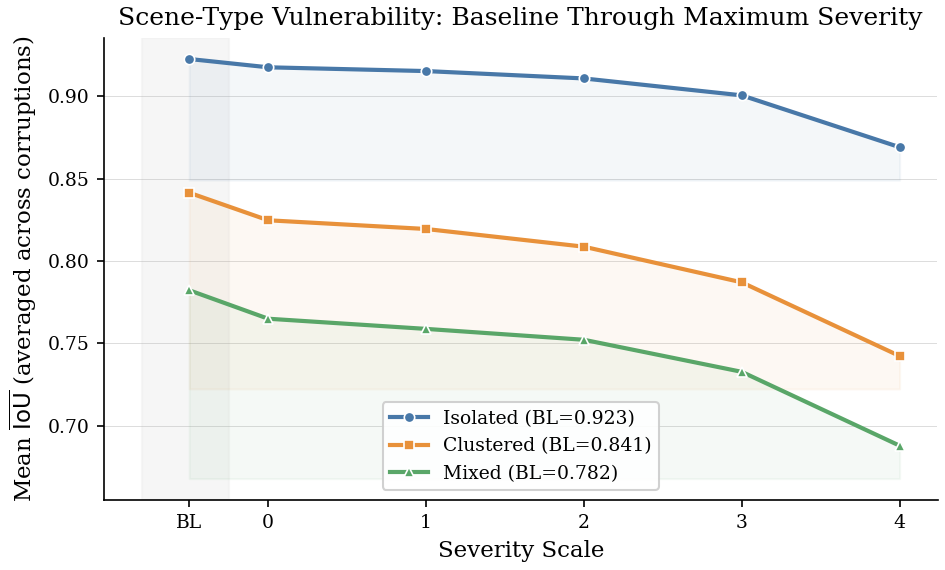

In [21]:
# ============================================================
# FIGURE 10: scene-type comparison : mean IoU per scene at each sev, averaged across corruptions
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 4.0))

for st in SCENE_ORDER:
    sub = df[df.scene_type == st]
    means = sub.groupby('severity')['IoU'].mean()
    vals = [bl_means[st]] + [means[s] for s in range(5)]
    ax.plot(x_pos, vals, marker=SCENE_MARKERS[st], markersize=5, linewidth=2.0,
            color=SCENE_COLORS[st], markeredgecolor='white', markeredgewidth=0.8,
            label=f'{st} (BL={bl_means[st]:.3f})')
    ax.fill_between(x_pos, vals, min(vals) - 0.02, color=SCENE_COLORS[st], alpha=0.06)

ax.axvspan(-0.8, -0.25, color='#f0f0f0', alpha=0.6, zorder=0)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Severity Scale')
ax.set_ylabel('Mean $\overline{\mathrm{IoU}}$ (averaged across corruptions)')
ax.set_title('Scene-Type Vulnerability: Baseline Through Maximum Severity')
ax.legend(framealpha=0.9)
style_ax(ax)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_overall.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_scene_type_overall.png'))
plt.show()

## Retention Justification

In [22]:
sev0_iou = df[df.severity == 0].groupby('corruption')['IoU'].mean()
sev4_iou = df[df.severity == 4].groupby('corruption')['IoU'].mean()
sev4_frob = df[df.severity == 4].groupby('corruption')['frobenius_distance'].mean()

ret_df = pd.DataFrame({
    'baseline_iou': bl_overall,
    'mean_IoU_sev0': sev0_iou,
    'mean_IoU_sev4': sev4_iou,
    'drop_sev0_to_4': sev0_iou - sev4_iou,
    'drop_BL_to_4': bl_overall - sev4_iou,
    'pct_drop_from_BL': ((bl_overall - sev4_iou) / bl_overall * 100),
    'mean_frob_sev4': sev4_frob,
}).round(5)

ret_df['status'] = ret_df.index.map(lambda c: 'Retained' if c in RETAINED else 'Excluded')
ret_df = ret_df.sort_values(['status', 'drop_BL_to_4'], ascending=[True, False])

display(ret_df)
ret_df.to_csv(os.path.join(OUTPUT_DIR, 'table_2d_retention.csv'))

,baseline_iou,mean_IoU_sev0,mean_IoU_sev4,drop_sev0_to_4,drop_BL_to_4,pct_drop_from_BL,mean_frob_sev4,status
corruption,,,,,,,,
false_color,0.84875,0.83220,0.75960,0.07260,0.08915,10.50352,0.31284,Excluded
elastic,0.84875,0.81958,0.78606,0.03351,0.06269,7.38578,0.07904,Excluded
cutout,0.84875,0.84035,0.79883,0.04151,0.04992,5.88113,0.18656,Excluded
contrast,0.84875,0.84478,0.82573,0.01905,0.02302,2.71277,0.11310,Excluded
snow_filter,0.84875,0.84105,0.82683,0.01421,0.02192,2.58208,0.29548,Excluded
grayscale,0.84875,0.84409,0.83096,0.01313,0.01779,2.09627,0.07189,Excluded
pixelate,0.84875,0.83085,0.65499,0.17586,0.19376,22.82838,0.10172,Retained
defocus_blur,0.84875,0.83689,0.69321,0.14368,0.15554,18.32573,0.10230,Retained
motion_blur,0.84875,0.83663,0.74362,0.09300,0.10512,12.38585,0.09109,Retained


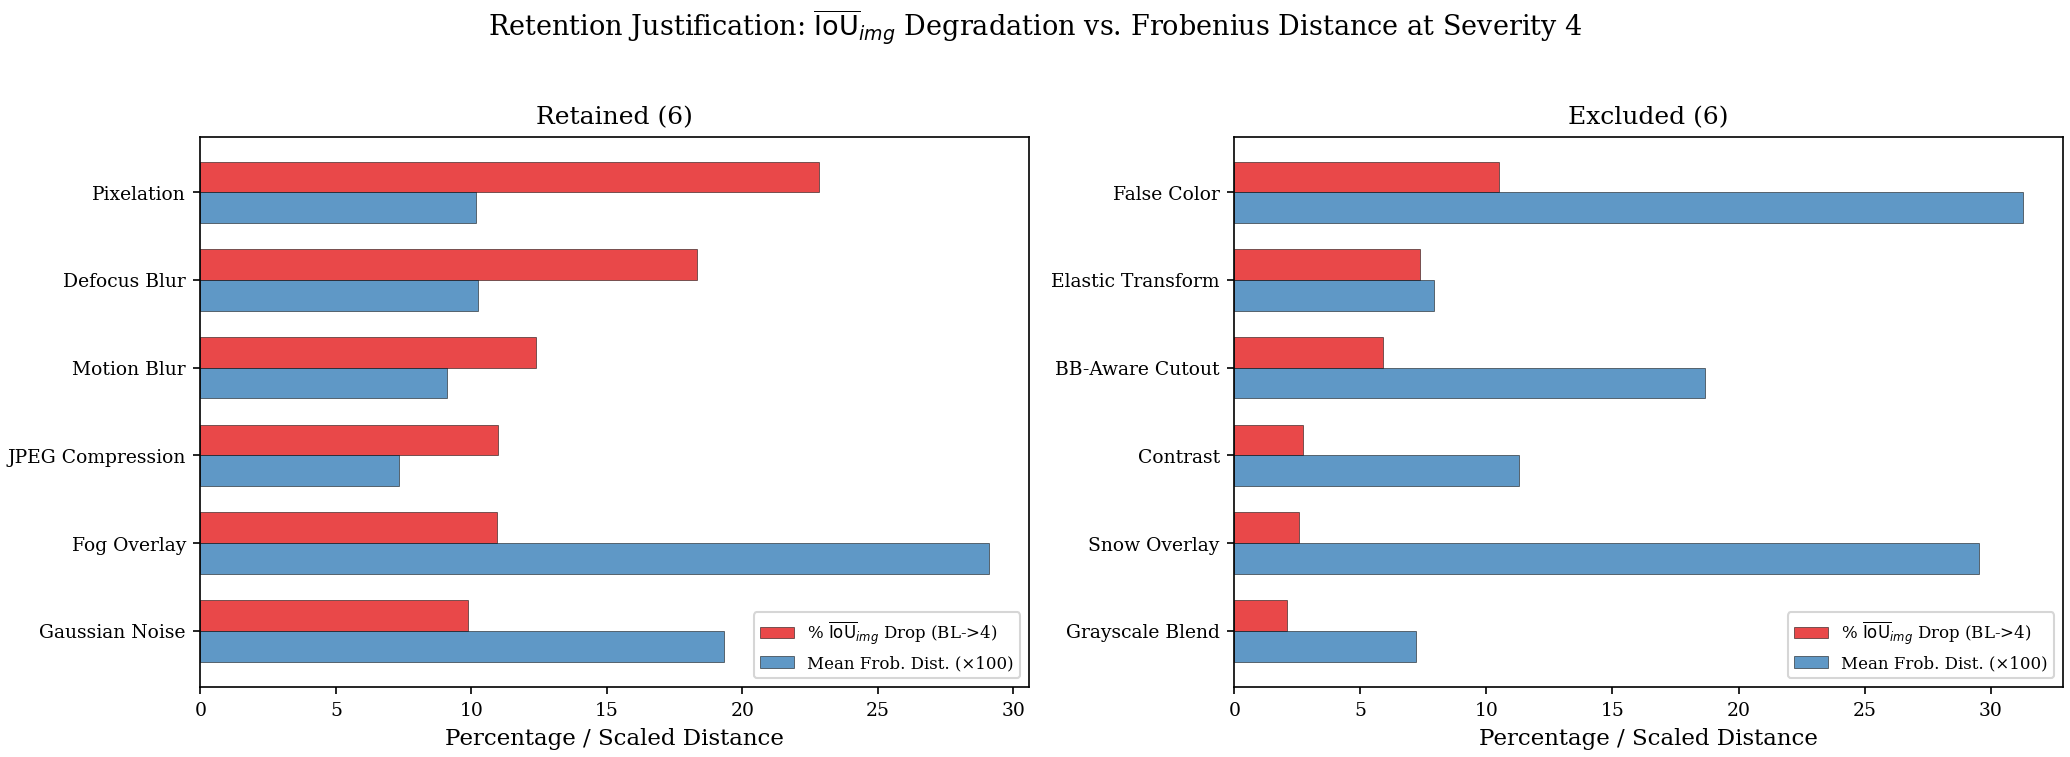

In [23]:
# ============================================================
# FIGURE 11: horizontal bar : % degradation from BL, split retained/excluded
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, group) in zip(axes, [('Retained (6)', RETAINED), ('Excluded (6)', EXCLUDED)]):
    sub = ret_df[ret_df.index.isin(group)].sort_values('pct_drop_from_BL', ascending=True)
    names = [NICE_NAMES.get(c, c) for c in sub.index]
    pcts = sub['pct_drop_from_BL'].values
    frobs = sub['mean_frob_sev4'].values

    y = np.arange(len(names))
    h = 0.35

    ax.barh(y + h/2, pcts, h, label='% $\overline{\mathrm{IoU}}_{img}$ Drop (BL->4)', color='#e41a1c', alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.barh(y - h/2, frobs * 100, h, label='Mean Frob. Dist. (×100)', color='#377eb8', alpha=0.8, edgecolor='black', linewidth=0.3)

    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlabel('Percentage / Scaled Distance')
    ax.set_title(label)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Retention Justification: $\overline{\mathrm{IoU}}_{img}$ Degradation vs. Frobenius Distance at Severity 4',
             fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_horizontal.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_horizontal.png'))
plt.show()

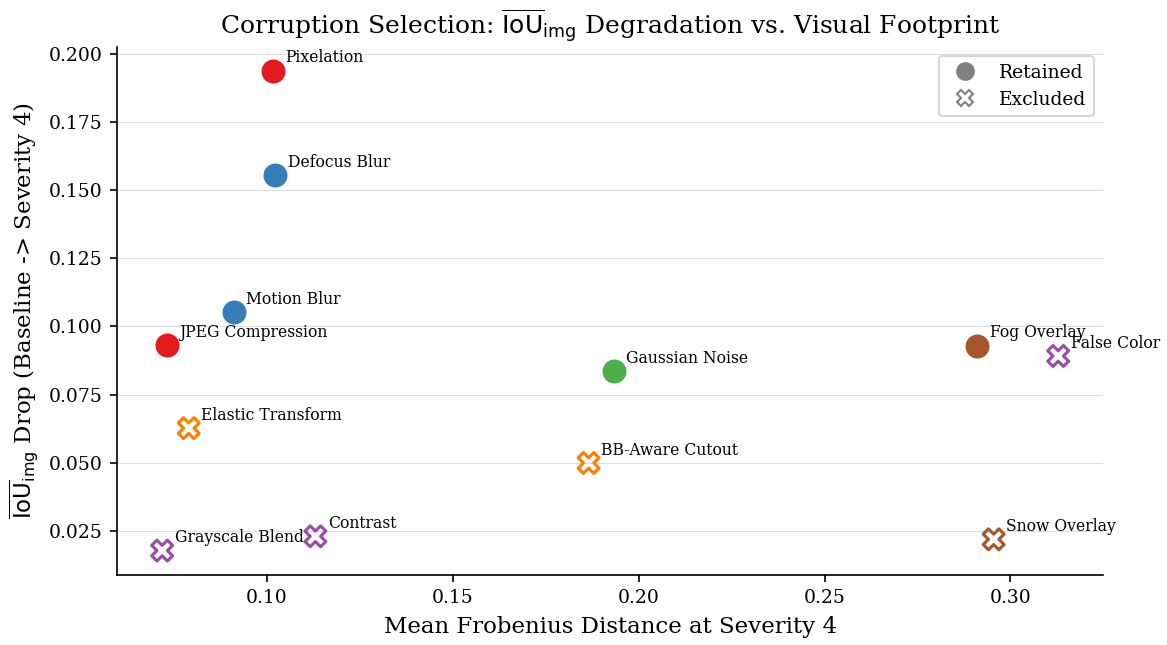

In [24]:
# ============================================================
# FIGURE 12: scatter : IoU drop vs Frobenius (retained=circle, excluded=x)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

for corr in ret_df.index:
    row = ret_df.loc[corr]
    marker = 'o' if corr in RETAINED else 'X'
    fc = CAT_COLORS[CATEGORY_MAP[corr]] if corr in RETAINED else 'none'
    ec = CAT_COLORS[CATEGORY_MAP[corr]]
    ax.scatter(row['mean_frob_sev4'], row['drop_BL_to_4'],
              marker=marker, s=100, c=fc, edgecolors=ec, linewidths=1.5, zorder=5)
    ax.annotate(NICE_NAMES.get(corr, corr),
               (row['mean_frob_sev4'], row['drop_BL_to_4']),
               textcoords='offset points', xytext=(6, 4), fontsize=7.5)

handles = [
    Line2D([0],[0], marker='o', color='gray', markersize=8, ls='', label='Retained'),
    Line2D([0],[0], marker='X', color='gray', markersize=8, ls='', markerfacecolor='none', label='Excluded'),
]
ax.legend(handles=handles, loc='upper right')

ax.set_xlabel('Mean Frobenius Distance at Severity 4')
ax.set_ylabel('$\overline{\mathrm{IoU}}_{\mathrm{img}}$ Drop (Baseline -> Severity 4)')
ax.set_title('Corruption Selection: $\overline{\mathrm{IoU}}_{\mathrm{img}}$ Degradation vs. Visual Footprint')

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_scatter.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_scatter.png'))
plt.show()

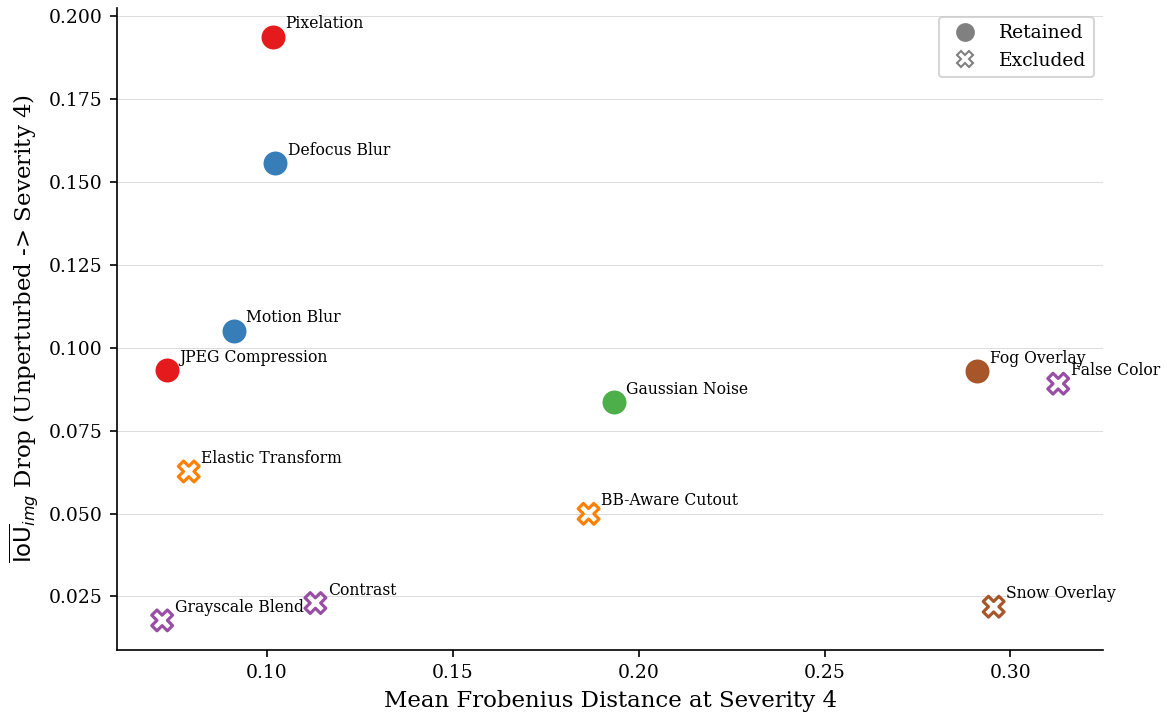

In [25]:
# ============================================================
# FIGURE 12: scatter : IoU drop vs Frobenius (retained=circle, excluded=x)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for corr in ret_df.index:
    row = ret_df.loc[corr]
    marker = 'o' if corr in RETAINED else 'X'
    fc = CAT_COLORS[CATEGORY_MAP[corr]] if corr in RETAINED else 'none'
    ec = CAT_COLORS[CATEGORY_MAP[corr]]
    ax.scatter(row['mean_frob_sev4'], row['drop_BL_to_4'],
              marker=marker, s=100, c=fc, edgecolors=ec, linewidths=1.5, zorder=5)
    ax.annotate(NICE_NAMES.get(corr, corr),
               (row['mean_frob_sev4'], row['drop_BL_to_4']),
               textcoords='offset points', xytext=(6, 4), fontsize=7.5)

handles = [
    Line2D([0],[0], marker='o', color='gray', markersize=8, ls='', label='Retained'),
    Line2D([0],[0], marker='X', color='gray', markersize=8, ls='', markerfacecolor='none', label='Excluded'),
]
ax.legend(handles=handles, loc='upper right')

ax.set_xlabel('Mean Frobenius Distance at Severity 4')
ax.set_ylabel('$\overline{\mathrm{IoU}}_{img}$ Drop (Unperturbed -> Severity 4)')
ax.set_title('')

style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_scatter_notitle.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_retention_scatter_notitle.png'))
plt.show()

## Token Count & Runtime (Efficiency)

In [26]:
tok_pivot = df.pivot_table(index='corruption', columns='severity', values='token_count', aggfunc='mean').round(1)
raw_tok_pivot = df.pivot_table(index='corruption', columns='severity', values='raw_token_count', aggfunc='mean').round(1)
runtime_pivot = df.pivot_table(index='corruption', columns='severity', values='runtime_seconds', aggfunc='mean').round(4)

print('=== Mean Visible Token Count ===')
display(tok_pivot)
print()
print('=== Mean Raw Token Count ===')
display(raw_tok_pivot)
print()
print('=== Mean Runtime (s) ===')
display(runtime_pivot)

tok_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2e_token_count.csv'))
raw_tok_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2e_raw_token_count.csv'))
runtime_pivot.to_csv(os.path.join(OUTPUT_DIR, 'table_2e_runtime.csv'))

=== Mean Visible Token Count ===


severity,0,1,2,3,4
corruption,,,,,
contrast,105.3,105.3,105.1,104.4,103.5
cutout,105.1,105.3,101.9,100.9,101.0
defocus_blur,101.3,91.6,90.0,84.4,79.0
elastic,97.8,100.2,97.6,98.5,96.0
false_color,104.1,104.2,104.5,99.6,94.9
fog_filter,107.3,103.5,102.4,103.3,91.6
gaussian_noise,104.1,102.8,101.1,93.7,94.2
grayscale,104.4,104.5,104.8,105.0,103.5
jpeg_filter,102.0,100.7,102.1,100.1,95.6



=== Mean Raw Token Count ===


severity,0,1,2,3,4
corruption,,,,,
contrast,265.3,259.4,260.6,266.6,263.6
cutout,253.2,260.9,251.7,242.4,254.2
defocus_blur,243.1,200.2,211.4,178.9,158.6
elastic,235.7,255.0,243.4,242.0,240.5
false_color,258.9,268.3,267.7,254.5,244.3
fog_filter,275.2,254.3,254.4,259.3,214.0
gaussian_noise,267.5,259.5,266.2,215.6,231.4
grayscale,250.1,251.2,253.7,257.9,259.5
jpeg_filter,255.0,246.4,251.8,254.3,242.1



=== Mean Runtime (s) ===


severity,0,1,2,3,4
corruption,,,,,
contrast,2.1515,2.7748,2.5283,2.7852,2.1414
cutout,2.0720,2.8166,2.4317,2.4716,2.1100
defocus_blur,1.9521,2.0888,2.1090,1.7857,1.2952
elastic,1.9079,2.6847,2.3732,2.4176,1.9507
false_color,2.0892,2.8613,2.6009,2.6444,2.0046
fog_filter,2.2441,2.6989,2.4857,2.6442,1.7689
gaussian_noise,2.1496,2.7411,2.6191,2.1958,1.9021
grayscale,2.0250,2.6839,2.5510,2.5950,2.1287
jpeg_filter,2.0352,2.5533,2.5349,2.5934,1.9843


Baseline visible tokens: 103.3 (n=750)
Baseline runtime: 21.044s (n=750)


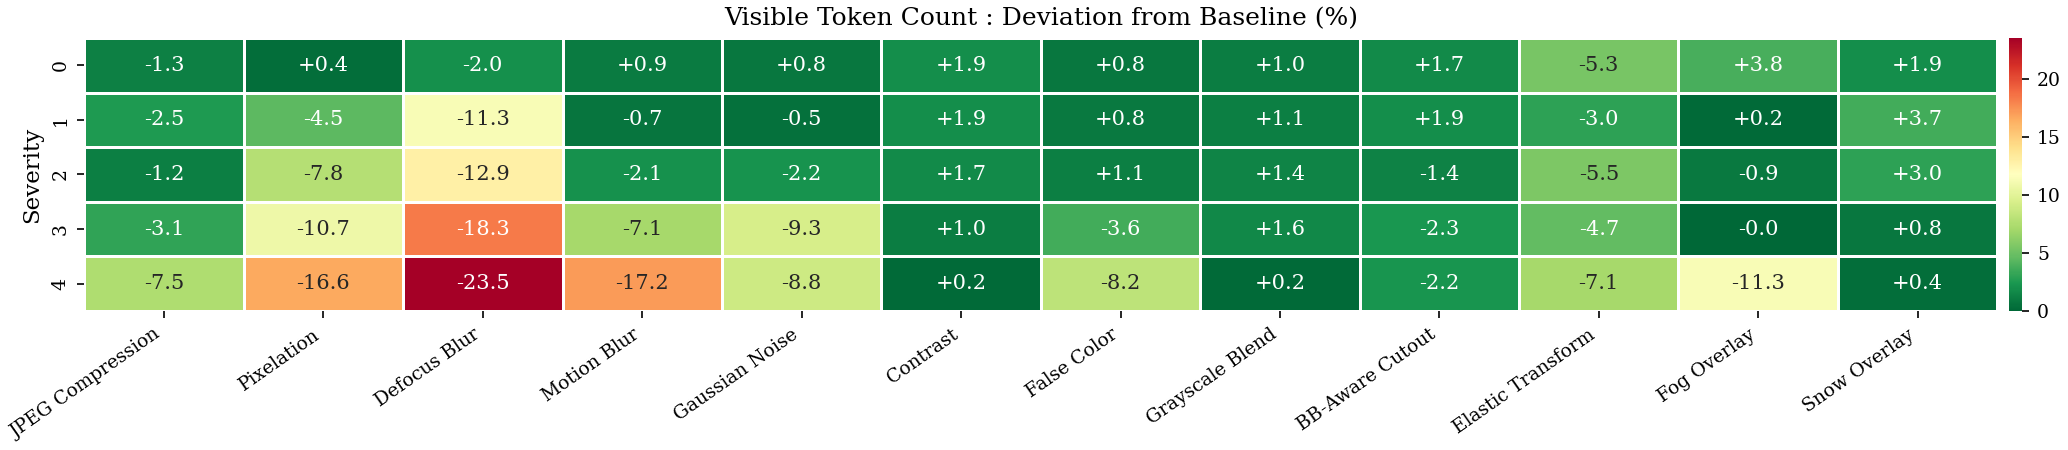

In [27]:
# ============================================================
# Efficiency: shared setup
# ============================================================
bl_tok_mean = bl['token_count'].mean()
bl_rt_mean  = bl['runtime'].mean()
print(f'Baseline visible tokens: {bl_tok_mean:.1f} (n={bl["token_count"].notna().sum()})')
print(f'Baseline runtime: {bl_rt_mean:.3f}s (n={bl["runtime"].notna().sum()})')

cat_order_corrs = []
for cat in CATEGORY_ORDER:
    cat_order_corrs.extend([c for c in sorted(CATEGORY_MAP.keys()) if CATEGORY_MAP[c] == cat])
tok_ordered = tok_pivot.reindex([c for c in cat_order_corrs if c in tok_pivot.index])
rt_ordered = runtime_pivot.reindex([c for c in cat_order_corrs if c in runtime_pivot.index])
nice_cols = [NICE_NAMES.get(c, c) for c in tok_ordered.index]

tok_h = tok_ordered.T
tok_h.columns = nice_cols
rt_h = rt_ordered.T
rt_h.columns = nice_cols

tok_pct = ((tok_h - bl_tok_mean) / bl_tok_mean) * 100
rt_pct  = ((rt_h  - bl_rt_mean)  / bl_rt_mean)  * 100

# ============================================================
# FIGURE 13a: Visible Token Count : % deviation from baseline
# ============================================================
tok_abs = tok_pct.abs()
tok_lim = tok_abs.max().max()

fig, ax = plt.subplots(figsize=(16, 3.2))
sns.heatmap(tok_abs, annot=tok_pct, fmt='+.1f', cmap='RdYlGn_r',
            vmin=0, vmax=tok_lim,
            linewidths=0.5, ax=ax, cbar_kws={'pad': 0.005})
ax.set_title('Visible Token Count : Deviation from Baseline (%)')
ax.set_ylabel('Severity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_token_deviation.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_token_deviation.png'))
plt.show()

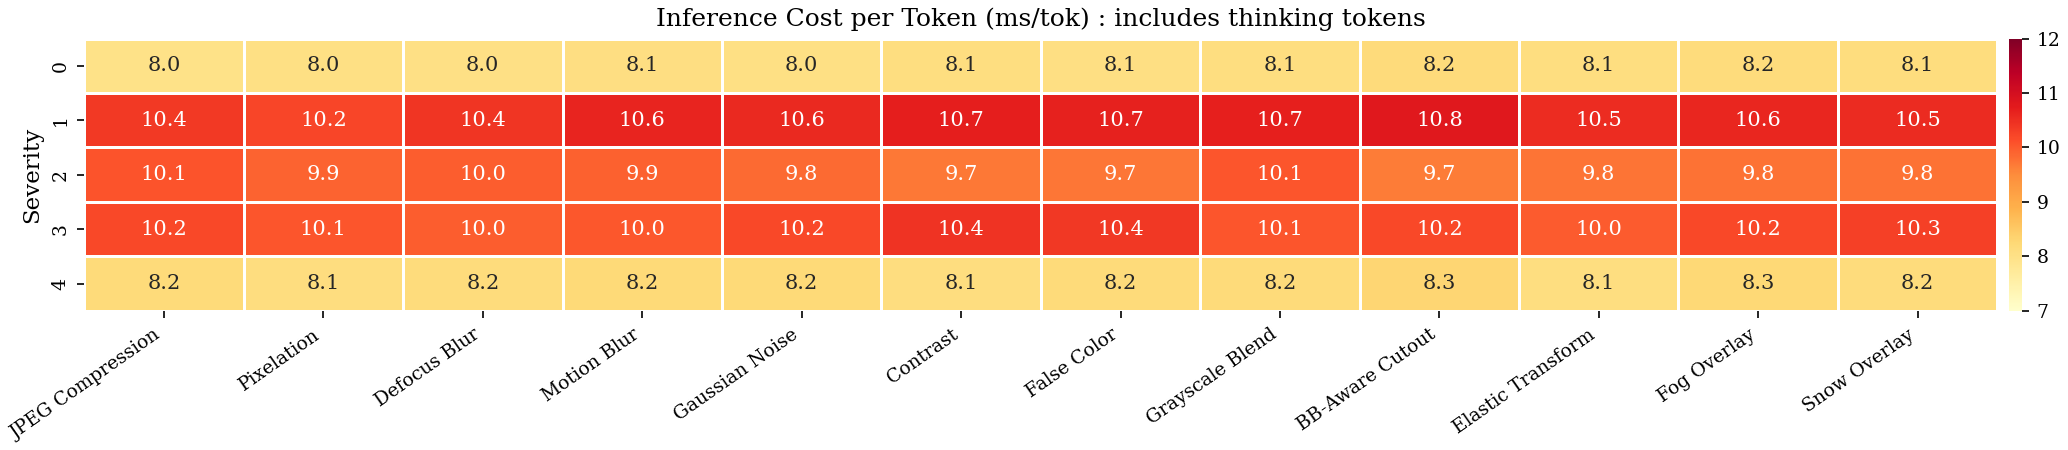

In [28]:
# ============================================================
# FIGURE 13b: Runtime : absolute (seconds)
# ============================================================
mspertok_pivot = (runtime_pivot * 1000) / raw_tok_pivot  # ms per token

mspertok_ordered = mspertok_pivot.reindex([c for c in cat_order_corrs if c in mspertok_pivot.index])
mspertok_h = mspertok_ordered.T
mspertok_h.columns = nice_cols

fig, ax = plt.subplots(figsize=(16, 3.2))
sns.heatmap(mspertok_h, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'pad': 0.005},
            vmin=7.0, vmax=12.0)
ax.set_title('Inference Cost per Token (ms/tok) : includes thinking tokens')
ax.set_ylabel('Severity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
style_ax(ax)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_ms_per_token_heatmap.pdf'))
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_ms_per_token_heatmap.png'))
plt.show()

## Formatted Tables

In [29]:
def piv_to_md(piv, idx_name='Corruption'):
    cols = [str(c) for c in piv.columns]
    hdr = f'| {idx_name} | ' + ' | '.join(cols) + ' |'
    sep = '|---' * (len(cols)+1) + '|'
    body = []
    for i in piv.index:
        vals = [str(piv.loc[i, c]) for c in piv.columns]
        body.append(f'| {i} | ' + ' | '.join(vals) + ' |')
    return '\n'.join([hdr, sep] + body)

print('### TABLE 2a : Per-Corruption IoU (with Baseline) ###')
print(piv_to_md(iou_pivot))
print()
print('### TABLE 2b : Category IoU ###')
print(piv_to_md(cat_pivot, 'Category'))
print()
print('### TABLE 2d : Retention ###')
print(ret_df.to_markdown())

### TABLE 2a : Per-Corruption IoU (with Baseline) ###
| Corruption | BL | 0 | 1 | 2 | 3 | 4 | drop_BL_to_4 | pct_drop |
|---|---|---|---|---|---|---|---|---|
| pixelate | 0.849 | 0.831 | 0.834 | 0.82 | 0.774 | 0.655 | 0.194 | 22.9 |
| defocus_blur | 0.849 | 0.837 | 0.804 | 0.784 | 0.746 | 0.693 | 0.156 | 18.4 |
| motion_blur | 0.849 | 0.837 | 0.837 | 0.833 | 0.818 | 0.744 | 0.105 | 12.4 |
| fog_filter | 0.849 | 0.843 | 0.843 | 0.837 | 0.823 | 0.756 | 0.093 | 11.0 |
| jpeg_filter | 0.849 | 0.82 | 0.822 | 0.817 | 0.808 | 0.756 | 0.093 | 11.0 |
| false_color | 0.849 | 0.832 | 0.829 | 0.836 | 0.803 | 0.76 | 0.089 | 10.5 |
| gaussian_noise | 0.849 | 0.84 | 0.83 | 0.813 | 0.791 | 0.765 | 0.084 | 9.9 |
| elastic | 0.849 | 0.82 | 0.819 | 0.799 | 0.795 | 0.786 | 0.063 | 7.4 |
| cutout | 0.849 | 0.84 | 0.833 | 0.825 | 0.815 | 0.799 | 0.05 | 5.9 |
| contrast | 0.849 | 0.845 | 0.84 | 0.84 | 0.832 | 0.826 | 0.023 | 2.7 |
| snow_filter | 0.849 | 0.841 | 0.839 | 0.84 | 0.836 | 0.827 | 0.022 | 2.6 |
|

In [30]:
print('### TABLE 2c : Scene-Type at Severity 4 ###')
print(sev4_scene.to_markdown())

### TABLE 2c : Scene-Type at Severity 4 ###
| corruption     |   Isolated |   Clustered |   Mixed |
|:---------------|-----------:|------------:|--------:|
| pixelate       |      0.781 |       0.624 |   0.56  |
| defocus_blur   |      0.823 |       0.651 |   0.605 |
| motion_blur    |      0.859 |       0.711 |   0.661 |
| jpeg_filter    |      0.856 |       0.737 |   0.674 |
| fog_filter     |      0.868 |       0.724 |   0.676 |
| false_color    |      0.857 |       0.738 |   0.683 |
| gaussian_noise |      0.879 |       0.731 |   0.685 |
| elastic        |      0.892 |       0.762 |   0.704 |
| cutout         |      0.88  |       0.778 |   0.738 |
| contrast       |      0.911 |       0.814 |   0.753 |
| snow_filter    |      0.91  |       0.815 |   0.755 |
| grayscale      |      0.912 |       0.822 |   0.759 |
